<a href="https://colab.research.google.com/github/prasa129/Econometrics/blob/main/Poisson_GLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Poisson GLM

10/12/2025

Implementation of Poisson GLM and demonstration using RANDHIE data.

## Data

I use RAND Health Insurance Experiment (HIE) bundled in statsmodels as randhie. The experiment's RCT assigned families to plans with different cost-sharing structures, thus out of pocket price is exogenous. The outcome of interest is mdvis, the number of outpatient MD visits.

Dimensions:
n =  20190, p = 10

Variables:

    mdvis   - Number of outpatient visits to an MD
    lncoins - ln(coinsurance + 1), 0 <= coinsurance <= 100
    idp     - 1 if individual deductible plan, 0 otherwise
    lpi     - ln(max(1, annual participation incentive payment))
    fmde    - 0 if idp = 1; ln(max(1, MDE/(0.01 coinsurance))) otherwise
    physlm  - 1 if the person has a physical limitation
    disea   - number of chronic diseases
    hlthg   - 1 if self-rated health is good
    hlthf   - 1 if self-rated health is fair
    hlthp   - 1 if self-rated health is poor
    (Omitted category is excellent self-rated health)

Note the omitted category for the health indicators avoids collinearity of the dummies with the intercept. I'll model outpatient visit count as a function of coinsurance and controls. The RCT permits clean identification. I answer the question: What is the causal effect of increasing patient cost-sharing on outpatient utilization?

Source:

https://www.statsmodels.org/dev/datasets/generated/randhie.html

https://cameron.econ.ucdavis.edu/mmabook/mmadata.html

I build the design matrix and spot check variable distributions.

Sample size n=20190, parameters p=10
Design columns: ['Intercept', 'ln(1+coins)', 'idp', 'lpi', 'fmde', 'physlm', 'disea', 'hlthg', 'hlthf', 'hlthp']


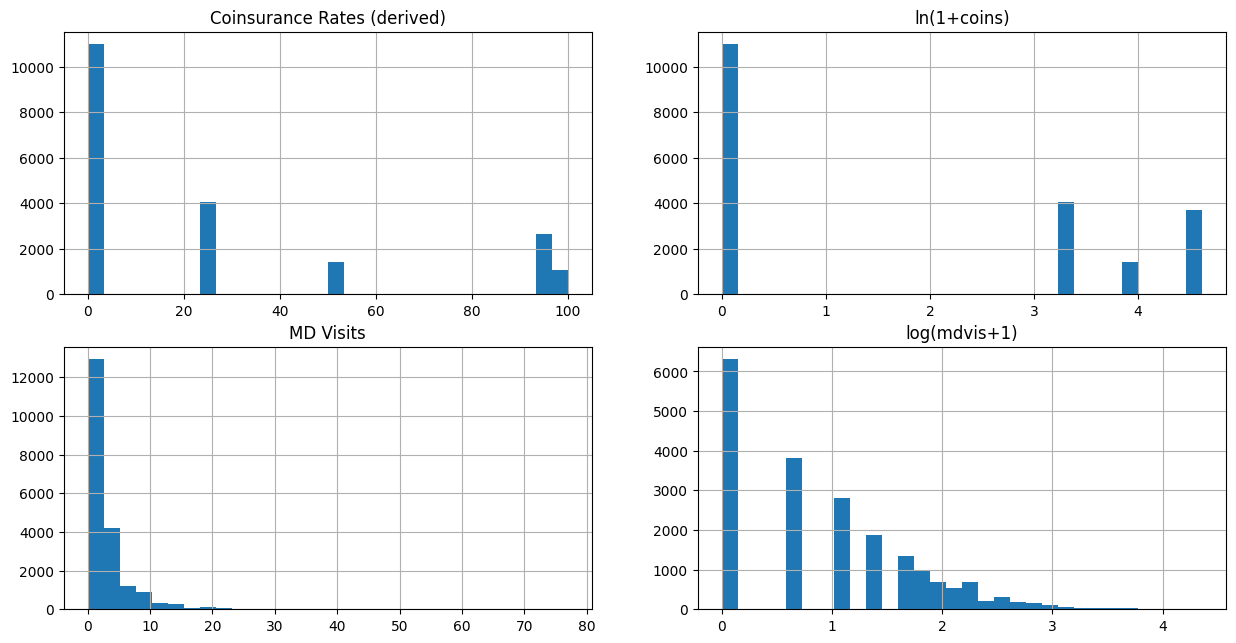

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# load RAND HIE dataset bundled with statsmodels
df = sm.datasets.randhie.load_pandas().data.copy()

# construct variables
# RAND HIE in statsmodels already includes lncoins ≈ log(1+coins)
df["coins"] = np.exp(df["lncoins"]) - 1.0
df["log_mdvis"] = np.log(df["mdvis"] + 1.0)

def build_design(df, y_col="mdvis", z_col="lncoins",
                 controls=("idp","lpi","fmde","physlm","disea","hlthg","hlthf","hlthp")):
    """
    Build the design for the Poisson GLM: y vector and X matrix with
    an intercept, ln(1+coins) regressor, and optional controls.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the outcome, ln(1+coins), and control columns.
    y_col : str, default "mdvis"
        Name of the count outcome column.
    z_col : str, default "lncoins"
        Name of the ln(1+coins) column.
    controls : tuple[str], optional
        Names of control variables to include if present in `df`.

    Returns
    -------
    y : (n,) ndarray
        Outcome vector.
    X : (n, p) ndarray
        Design matrix with columns [Intercept, ln(1+coins), controls...].
    names : list[str]
        Column names corresponding to X’s columns.
    """
    # keep controls that exist in df
    cols = [c for c in controls if c in df.columns]

    # controls matrix (or empty if none)
    X = df.loc[:, cols].to_numpy(dtype=float) if cols else np.empty((len(df), 0))

    # ln(1+coins) as a 2D column
    z = df[z_col].to_numpy(dtype=float)[:, None]

    # intercept column
    intercept = np.ones((len(df), 1))

    # assemble [intercept, z, controls]
    X_full = np.hstack([intercept, z, X])

    # outcome vector
    y = df[y_col].to_numpy(dtype=float)

    # names for reporting
    names = ["Intercept", "ln(1+coins)"] + cols

    return y, X_full, names

# construct design matrix
y, X, names = build_design(df)

# capture dimensions
n, p = X.shape
print(f"Sample size n={n}, parameters p={p}")
print('Design columns:', names)

# plot distributions of response and price variables
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15,7.5))

axs[0][0].hist(df["coins"], bins=30)
axs[0][0].set_title("Coinsurance Rates (derived)")

axs[1][0].hist(df["mdvis"], bins=30)
axs[1][0].set_title("MD Visits")

# log-transformed variables
axs[0][1].hist(df["lncoins"], bins=30)
axs[0][1].set_title("ln(1+coins)")

axs[1][1].hist(df["log_mdvis"], bins=30)
axs[1][1].set_title("log(mdvis+1)")

# grids
for i in [0,1]:
    for j in [0,1]:
        axs[i][j].grid(True)
plt.show()

An immediate issue is the excess zeros in the count of outpatient visits.

## Model

Assume counts of MD visits are conditionally independent, meaning, conditional on covariates, observations are independent. This is reasonable given the experimental setup. Counts are non-negative, so I use a Poisson GLM.

\begin{align*}
Y_{i} | X_{i} \sim \text{Poisson}(\mu_{i}), \text{ }E[Y_{i}|X_{i}] = \mu_{i} > 0 \\
\text{ln}(\mu_{i}) = \beta_{0} + \beta_{1}\text{ln}(1+\text{coins}_{i}) + X_{i}^{T}\gamma \\
\end{align*}

The parameter of interest is $\beta_{1}$, the elasticity of expected number of outpatient visits with respect to coinsurance:

$$
\beta_{1} = \frac{\partial \text{ln} \mu_{i}}{ \partial \text{ln}(1+ \text{coins}_{i} ) }
$$

Given the distributional assumptions, I estimate $\hat{\beta}_{1}$ using MLE:

\begin{align*}
P(Y_{i}=y_{i}|\mu_{i}) &= \frac{e^{-\mu_{i}}\mu_{i}^{y_{i}}}{ y_{i}! }, \text{ }y_{i} = 0,1,2... \\
L(\beta_{0}, \beta_{1}, \gamma) &= \prod_{i=1}^{n}P(Y_{i}=y_{i}|\mu_{i}) \\
&= e^{-\sum_{i=1}^{n}\mu_{i}}  \prod_{i=1}^{n}\frac{\mu_{i}^{y_{i}}}{ y_{i}! } \\
\text{ln} L(\beta_{0}, \beta_{1}, \gamma) &= -\sum_{i=1}^{n}\mu_{i} + \sum_{i=1}^{n}\left( y_{i}\text{ln}(\mu_{i}) -\text{ln}(y_{i}!)\right) \\
\mathcal{l}(\beta_{0}, \beta_{1}, \gamma) &= \sum_{i=1}^{n} \left[  y_{i}\text{ln}(\mu_{i}) -\text{ln}(y_{i}!) - \mu_{i}  \right] \\
&= \sum_{i=1}^{n} \left[y_{i}(\beta_{0} + \beta_{1}\text{ln}(1+\text{coins}_{i}) + X_{i}^{T}\gamma) - e^{\beta_{0} + \beta_{1}\text{ln}(1+\text{coins}_{i}) + X_{i}^{T}\gamma} \right] - \sum_{i=1}^{n}\text{ln}(y_{i}!)
\end{align*}

Let $z_{i} \equiv \text{ln}(1+\text{coins}_{i}), w_{i} \equiv (1, z_{i}, X_{i}^{T})^{T}, \theta \equiv (\beta_{0}, \beta_{1}, \gamma)^{T}, \mu_{i} = \text{exp}(w_{i}^{T}\theta)$:

$$
\mathcal{l}(\theta) = \sum_{i=1}^{n} [y_{i}w_{i}^{T}\theta - \text{exp}(w_{i}^{T}\theta) ] - \sum_{i=1}^{n}\text{ln}(y_{i}!)
$$

Using $\partial \mu_i / \partial \theta = \mu_i w_i$,
$$
\frac{\partial \ell}{\partial \theta} = \sum_{i=1}^n w_i \,(y_i-\mu_i)
$$
which componentwise yields

\begin{align*}
\frac{\partial \ell}{\partial \beta_0} &= \sum_{i=1}^n (y_i-\mu_i),\\
\frac{\partial \ell}{\partial \beta_1} &= \sum_{i=1}^n z_i\,(y_i-\mu_i),\\
\nabla_{\gamma}\ell &= \sum_{i=1}^n X_i\,(y_i-\mu_i).
\end{align*}

Thus $\hat\theta_{\text{MLE}}$ solves $\sum_{i=1}^n w_i (y_i-\hat\mu_i)=0$.

## Implementation and Estimation

I implement the model from scratch, using iteratively reweighted least squares for optimization. The IRLS algorithm is as follows:

0. Initialize $\theta^{(0)}$ and set iteration counter $t ← 0$

Until covergence or $t = T_{\max}$, at iteration $t$:

1. Compute linear predictor $\eta^{(t)} = X \theta^{(t)}$ and mean $\mu^{(t)} = \text{exp}(\eta^{(t)})$

2. Compute score $s^{(t)} = \frac{\partial l}{\partial \theta} = X^{T}(y-\mu^{(t)})$ and Hessian $H^{(t)} = \frac{ \partial^{2} l }{\partial \theta \partial \theta^{T}} = -X^{T}W^{(t)}X$ using weights $W^{(t)} = \text{diag}(\mu^{(t)})$

3. Compute the Newton step using GLM normal equations. Solve $(X^{T}W^{(t)}X)\Delta^{(t)} = X^{T}(y - \mu^{(t)})$ to obtain $\Delta^{(t)} = -(H^{(t)})^{-1}s^{(t)}$

4. Update parameters $\theta^{(t+1)} \leftarrow \theta^{(t)} + \alpha \Delta^{(t)}$

5. Check convergence. If change in parameters and/or log-likelihood is within tolerance, stop. Otherwise set $t \leftarrow t+1$ and repeat.

In [2]:
def poisson_loglik(theta, X, y):
    """
    Poisson log-likelihood (up to the constant -sum log(y!)) with log link.

    Parameters
    ----------
    theta : (p,) ndarray
        Parameter vector.
    X : (n, p) ndarray
        Design matrix.
    y : (n,) ndarray
        Count outcome.

    Returns
    -------
    ll : float
        Log-likelihood value (constant -sum log(y!) omitted).
    """
    # linear predictor
    eta = X @ theta

    # mean under log link
    mu = np.exp(eta)

    # log-likelihood (constant terms omitted)
    ll = np.sum(y * eta - mu)

    return ll


def poisson_score(theta, X, y):
    """
    Score vector for the Poisson GLM with log link.

    Parameters
    ----------
    theta : (p,) ndarray
        Parameter vector.
    X : (n, p) ndarray
        Design matrix.
    y : (n,) ndarray
        Count outcome.

    Returns
    -------
    s : (p,) ndarray
        Score vector X'(y - mu).
    mu : (n,) ndarray
        Fitted mean vector exp(X @ theta).
    """
    # linear predictor
    eta = X @ theta

    # mean under log link
    mu = np.exp(eta)

    # score vector X'(y - mu)
    s = X.T @ (y - mu)

    return s, mu


def poisson_hessian(theta, X):
    """
    Observed Hessian (second derivative) for the Poisson GLM.

    Parameters
    ----------
    theta : (p,) ndarray
        Parameter vector.
    X : (n, p) ndarray
        Design matrix.

    Returns
    -------
    H : (p, p) ndarray
        Observed Hessian = -X' diag(mu) X, with mu = exp(X @ theta).
    mu : (n,) ndarray
        Fitted mean vector exp(X @ theta).
    """
    # linear predictor
    eta = X @ theta

    # mean under log link
    mu = np.exp(eta)

    # observed Hessian = - X' diag(mu) X
    H = -(X.T * mu) @ X

    return H, mu


def fit_poisson_mle(X, y, tol=1e-8, maxiter=200):
    """
    Fit a Poisson GLM by Newton/IRLS using only NumPy.

    Iterates: theta_{t+1} = theta_t + (X'WX)^{-1} X'(y - mu),
    with W = diag(mu) and mu = exp(X @ theta).

    Parameters
    ----------
    X : (n, p) ndarray
        Design matrix.
    y : (n,) ndarray
        Count outcome.
    tol : float, default 1e-8
        Convergence tolerance on the log-likelihood change.
    maxiter : int, default 200
        Maximum number of Newton iterations.

    Returns
    -------
    out : dict
        Dictionary with keys:
        - "params": (p,) ndarray, MLE coefficients.
        - "se": (p,) ndarray, model-based standard errors.
        - "cov": (p, p) ndarray, model-based covariance (inverse observed info).
        - "H": (p, p) ndarray, observed Hessian at the solution.
        - "mu": (n,) ndarray, fitted means exp(X @ params).
        - "loglik": float, final log-likelihood (const omitted).
    """
    # initialize parameter vector, it counter
    theta = np.zeros(X.shape[1])
    it = 0.0

    # initialize previous log-likelihood
    ll_old = -np.inf

    # iterate Newton updates
    for _ in range(maxiter):

        # Score and Hessian at current theta
        s, _ = poisson_score(theta, X, y)
        H, _ = poisson_hessian(theta, X)

        # compute Newton step, fallback to pinv if singular
        try:
            step = np.linalg.solve(-H, s)
        except np.linalg.LinAlgError:
            step = np.linalg.pinv(-H) @ s

        # update parameter vector (alpha=1)
        theta_new = theta + step

        # evaluate new log-likelihood
        ll_new = poisson_loglik(theta_new, X, y)

        # convergence check
        if np.abs(ll_new - ll_old) < tol:
            theta = theta_new
            break

        # stage next iteration
        theta, ll_old = theta_new, ll_new
        it += 1

    # final score, Hessian, and mean
    _, mu = poisson_score(theta, X, y)
    H, _ = poisson_hessian(theta, X)

    # model-based covariance (inverse observed information)
    cov = np.linalg.pinv(-H)

    # standard errors
    se = np.sqrt(np.diag(cov))

    # package results
    out = {"params": theta,
           "se": se,
           "cov": cov,
           "H": H,
           "mu": mu,
           "loglik": poisson_loglik(theta, X, y),
           "iters":it}

    return out

# fit model
fit = fit_poisson_mle(X, y)

# capture param estimates and se
params = fit["params"]
se = fit["se"]

# MLE LL and iterations
print("Poisson MLE Est.")
print(f"Log-likelihood: {np.round(fit['loglik'],3)}, iter: {fit['iters']}")

# check results
poisson_results = pd.DataFrame({"Parameter": names, "Estimate": params, "SE": se}).T
poisson_results.columns = poisson_results.iloc[0]
poisson_results = poisson_results.iloc[1:]
display(poisson_results)

Poisson MLE Est.
Log-likelihood: 7171.244, iter: 11.0


Parameter,Intercept,ln(1+coins),idp,lpi,fmde,physlm,disea,hlthg,hlthf,hlthp
Estimate,0.700353,-0.052535,-0.247087,0.03529,-0.034578,0.271714,0.033941,-0.012635,0.054056,0.206115
SE,0.011163,0.002884,0.010617,0.001828,0.001613,0.012239,0.000565,0.009251,0.01531,0.026279


The Hessian is:

$$
\frac{\partial^2 \ell}{\partial \theta\, \partial \theta^\top}
= - \sum_{i=1}^n \mu_i \, w_i w_i^{T}
$$

e.g.

\begin{align*}
\frac{\partial^2 \ell}{\partial \beta_0^2} &= -\sum_i \mu_i, &
\frac{\partial^2 \ell}{\partial \beta_1^2} &= -\sum_i \mu_i z_i^2, &
\frac{\partial^2 \ell}{\partial \gamma\,\partial \gamma^\top} &= -\sum_i \mu_i X_i X_i^\top,\\
\frac{\partial^2 \ell}{\partial \beta_0\,\partial \beta_1} &= -\sum_i \mu_i z_i, &
\frac{\partial^2 \ell}{\partial \beta_0\,\partial \gamma} &= -\sum_i \mu_i X_i, &
\frac{\partial^2 \ell}{\partial \beta_1\,\partial \gamma} &= -\sum_i \mu_i z_i X_i.
\end{align*}



In [3]:
# capture Hessian
H = fit["H"]

# display
print("Hessian:")
pd_H = pd.DataFrame(H, columns=names, index=names)
display(pd_H.round(3))

# check against X'WX
eta = X @ params
mu = np.exp(eta)

# X'WX with W=diag(mu)
XWX = (X.T * mu) @ X

# ensure Hessian ND and within tol
print("Max abs diff between -H and X'WX:", np.max(np.abs(-H - XWX)))
print("Hessian is negative definite? (eigs):", np.all(np.linalg.eigvals(H) < 1e-8))


Hessian:


,Intercept,ln(1+coins),idp,lpi,fmde,physlm,disea,hlthg,hlthf,hlthp
Intercept,-57752.000,-89890.516,-12982.000,-267825.703,-201875.646,-11333.732,-7.793331e+05,-21213.000,-5760.000,-1750.000
ln(1+coins),-89890.516,-357524.430,-12454.687,-542182.379,-553589.953,-16522.064,-1.213679e+06,-33443.622,-8971.599,-1813.578
idp,-12982.000,-12454.687,-12982.000,-69365.401,-53978.445,-2318.509,-1.750720e+05,-5076.442,-1297.372,-317.346
lpi,-267825.703,-542182.379,-69365.401,-1660925.900,-1206690.851,-50998.989,-3.606079e+06,-98158.989,-25548.469,-7931.238
fmde,-201875.646,-553589.953,-53978.445,-1206690.851,-1421334.217,-38463.575,-2.653040e+06,-74355.889,-19644.626,-4605.824
physlm,-11333.732,-16522.064,-2318.509,-50998.989,-38463.575,-11083.303,-2.347174e+05,-4641.104,-2738.424,-1305.790
disea,-779333.123,-1213679.009,-175072.019,-3606078.653,-2653039.715,-234717.386,-1.462073e+07,-305668.279,-106520.022,-43726.450
hlthg,-21213.000,-33443.622,-5076.442,-98158.989,-74355.889,-4641.104,-3.056683e+05,-21213.000,0.000,0.000
hlthf,-5760.000,-8971.599,-1297.372,-25548.469,-19644.626,-2738.424,-1.065200e+05,0.000,-5760.000,0.000
hlthp,-1750.000,-1813.578,-317.346,-7931.238,-4605.824,-1305.790,-4.372645e+04,0.000,0.000,-1750.000


Max abs diff between -H and X'WX: 0.0
Hessian is negative definite? (eigs): True


All entries are non-positive, and diagonals are especially negative, consistent with a Poisson log-likelihood near the maximum. Diagonal entries are large (in magnitude), thus SEs are low and estimates are precise for disea, lpi. Zero values for off-diagonals among health categories result from mutually exclusive indicators, as the weighted cross product is naturally zero.  

## Inference

I compute standard errors and robust standard errors. The asymptotic distribution requires the Fisher information:

$$
\mathcal I(\theta)=\mathbb{E}\!\left[-\ell''(\theta)\right]
= \sum_{i=1}^n \mu_i \, w_i w_i^{T}
$$


Let $X$ be the $n\times p$ design matrix with rows $w_{i}^{T}$, and $W=\mathrm{diag}(\mu_1,\dots,\mu_n)$. Then

$$
-\ell''(\theta)=X^\top W X, \qquad \mathcal I(\theta)=X^\top W X.
$$

Under standard regularity,

$$
\sqrt{n}\,(\hat\theta-\theta_0)\ \overset{d}{\longrightarrow}\ \mathcal N\!\big(0,\ \mathcal I(\theta_0)^{-1}\big).
$$

Thus the model-based covariance at $\hat{\theta}(\hat{\mu_{i}}=\text{exp}(w_{i}^{T} \hat{\theta}))$ is

$$
\widehat{\mathrm{Var}}(\hat\theta) = \big(X^\top \hat W X\big)^{-1},\qquad \hat W=\mathrm{diag}(\hat\mu_i)
$$

and the Wald $z$-statistic for $\beta_{1}$ is

$$
z=\frac{\hat{\beta_{1}}}{\sqrt{\widehat{\mathrm{Var}}(\hat{\beta_{1}})}} \;\;\overset{a}{\sim}\;\; \mathcal N(0,1).
$$

I obtain z-stats:

In [4]:
# Fisher info at MLE = X'WX
fisher = XWX.copy()

# model based covariance
cov_model = np.linalg.pinv(fisher)

# z stats
z_stats = params / np.sqrt(np.diag(cov_model))

# check params, est, se, z - stat
poisson_results.loc["z-stat"] = z_stats
display(poisson_results)

Parameter,Intercept,ln(1+coins),idp,lpi,fmde,physlm,disea,hlthg,hlthf,hlthp
Estimate,0.700353,-0.052535,-0.247087,0.03529,-0.034578,0.271714,0.033941,-0.012635,0.054056,0.206115
SE,0.011163,0.002884,0.010617,0.001828,0.001613,0.012239,0.000565,0.009251,0.01531,0.026279
z-stat,62.74064,-18.216128,-23.272199,19.301805,-21.438781,22.200417,60.098406,-1.365859,3.530816,7.843255


To accommodate variance misspecification/overdispersion while keeping the Poisson mean, I compute robust covariance:
$$
\widehat{\mathrm{Var}}_{\text{robust}}(\hat\theta)
= \big(X^\top \hat W X\big)^{-1}
\left(\sum_{i=1}^n w_i w_i^\top\,\hat u_i^2\right)
\big(X^\top \hat W X\big)^{-1},
\qquad \hat u_i = y_i-\hat\mu_i\;
$$

with an HC1 small-sample correction, scaling the inner term by $n/(n-p)$.

In [5]:
# compute residuals
resid = y - fit["mu"]

# robust covar. matrix inner X' diag(resid^2) X
rcov_inner = X.T * resid**2 @ X

# small sample scaling
hc1 = n/(n-p)

# robust covariance
cov_robust = cov_model @ (rcov_inner * hc1) @ cov_model

# robust se and z-stat
robust_se = np.sqrt(np.diag(cov_robust))
z_stats_robust = params / robust_se

# check robust se
poisson_results.loc["Robust SE"] = robust_se
poisson_results.loc["z-stat (robust)"] = z_stats_robust
display(poisson_results)


Parameter,Intercept,ln(1+coins),idp,lpi,fmde,physlm,disea,hlthg,hlthf,hlthp
Estimate,0.700353,-0.052535,-0.247087,0.03529,-0.034578,0.271714,0.033941,-0.012635,0.054056,0.206115
SE,0.011163,0.002884,0.010617,0.001828,0.001613,0.012239,0.000565,0.009251,0.01531,0.026279
z-stat,62.74064,-18.216128,-23.272199,19.301805,-21.438781,22.200417,60.098406,-1.365859,3.530816,7.843255
Robust SE,0.02856,0.007207,0.026842,0.004608,0.004138,0.03308,0.001577,0.02243,0.042489,0.077027
z-stat (robust),24.522349,-7.289675,-9.205255,7.658437,-8.355818,8.213771,21.518277,-0.563315,1.272247,2.675873


A robust 95% CI for $\hat{\beta}_{1}$ is $-0.0525 \pm 1.96 \cdot 0.00721 = [-0.0666, -0.0384]$.

## Post-hoc Analysis

With the model fitted, I perform post-hoc analysis using marginal effects and IRR.

Marginal Effect (level)

\begin{align*}
\mu_{i} &= \text{exp}(\beta_{0} + \beta_{1}\text{ln}(1+\text{coins}_{i}) + X_{i}^{T}\gamma) \\
\frac{\partial \mu_i}{\partial \text{coins}_i} &= \frac{\beta_1}{1+\text{coins}_i}\,\mu_i.
\end{align*}

Incidence Rate Ratio

Let $(1 + \text{coins}_{i}) \rightarrow c \cdot (1+\text{coins}_{i})$ for $c > 0$.

\begin{align*}
\text{IRR}(c) &\equiv \frac{\mu_{i}(c + c \cdot \text{coins}_{i})}{\mu_{i}(1+ \text{coins}_{i})} \\
&= \left(\frac{c(1 + \text{coins}_{i})}{1 +\text{coins}_{i}}\right) ^{\beta_{1}} = c^{\beta_{1}}
\end{align*}

If $(1+\text{coins}_i)$ is multiplied by $c>0$, then $\mu_i$ is multiplied by $c^{\beta_{1}}$.

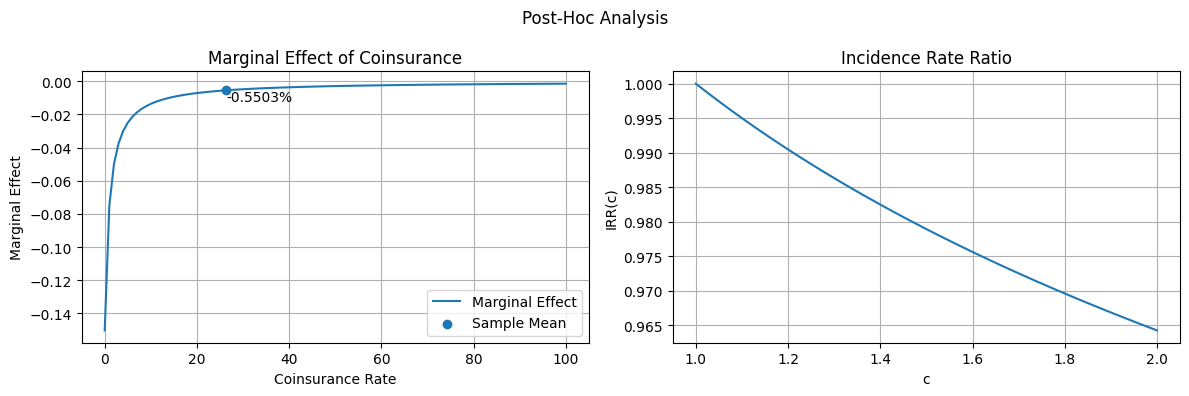

In [6]:
# compute marginal effect
def marginal_effect(beta_1, coins, mu): return mu*beta_1 / (1.0 + coins)

# beta_1 est, avg. mu
beta_1 = params[1]
coins_mean = df["coins"].mean()
mu_bar = fit["mu"].mean()

# grid
m_effect_grid = pd.DataFrame({"Coinsurance Rate":np.linspace(0.0,100.0,101)})
m_effect_grid["Marginal Effect"] = marginal_effect(beta_1, m_effect_grid["Coinsurance Rate"], mu_bar)


#subplots
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

# plot ME against grid
ax = axs[0]
ax.plot(m_effect_grid["Coinsurance Rate"], m_effect_grid["Marginal Effect"], label="Marginal Effect")

#labels, title
ax.set_xlabel("Coinsurance Rate")
ax.set_ylabel("Marginal Effect")
ax.set_title("Marginal Effect of Coinsurance")

# compute marginal effect of coinsurance at sample means
me_sample_mean = marginal_effect(beta_1, coins_mean, mu_bar)

# overlay on plot
ax.scatter(coins_mean, me_sample_mean, label="Sample Mean")

# annotate
ax.text(coins_mean, me_sample_mean, f"{np.round(100*me_sample_mean, 4)}%", va="top")

# display
ax.legend()
ax.grid()


# 1.0 -> 2.0 (10% to 100% increase)
irr_grid = np.linspace(1.0,2.0,101)

# plot IRR across grid
ax = axs[1]
ax.plot(irr_grid, irr_grid**beta_1)

#label, title
ax.set_xlabel("c")
ax.set_ylabel("IRR(c)")
ax.set_title("Incidence Rate Ratio")
ax.grid()

#display
plt.suptitle("Post-Hoc Analysis")
plt.tight_layout()
plt.show()

IRR shows the multiplicative change in expected outpatient visit count for multiplicative scaling of 1 + coins. IRR < 1, thus increasing coinsurance rates lowers hospital utilization.

- +10% in 1 + coins (c=1.10) $\approx$ 0.995, or 0.5% fewer visits
- +25% $\approx$ 0.988, or 1.2% fewer visits
- +100% (doubling) $\approx$ 0.964, or 3.6% fewer visits


I interpret the results as follows:

1. The estimate $\hat{\beta}_{1}=-0.052535$ is statistically significant (z=-7.29). A 1% increase in 1+coins $\textit{reduces}$ expected outpatient visits by 0.0525%, holding other covariates fixed. The price elasticity of outpatient utilization is small in magnitude, but precisely estimated. A modest increase in cost-sharing leads to statistically significant reductions in expected visits.

2. Robust SEs are uniformly larger than model based SEs, which is to be expected given heteroskedastcity in counts. Even with robust SEs, key effects are statistically significant, although some health indicators are not.

The results cohere with the intuition that demand for outpatient visits is largely price inelastic. When people need a doctor, they'll go regardless of coinsurance. Cost-sharing may impact the decision to go at the margin.

## Linear Probability Model

I fit a linear probability model as a robustness check. The model similarly estimates the effect of coinsurance (price) on use of outpatient visits. $Y_{i}$ is outpatient visits for person $i$, and $P_{i} = \text{ln}(\text{coins}_{i} + 1)$ is the randomized price measure. I use a log-log transform to stabilize skewness in response variable:

$$
\text{ln}(Y_{i}+1) = \beta_{0} + \beta_{1}\text{ln}(\text{coins}_{i} + 1) + X_{i}^{T}\gamma + u_{i}, \\
E[u_{i}|P_{i},X_{i}]=0
$$

The implementation below uses HC1 SE and least squares optimization.

In [7]:
# vectorize Y
Y = df['log_mdvis'].to_numpy()

# estimate beta with least squares
beta_ols = np.linalg.lstsq(X, Y, rcond=None)[0]

# compute residuals
resid_ols = Y - X @ beta_ols

# HC1 SE
S = ((X.T * (resid_ols**2)) @ X) * (n/(n-p))
cov_ols = np.linalg.pinv(X.T @ X) @ S @ np.linalg.pinv(X.T @ X)
se_ols = np.sqrt(np.diag(cov_ols))

# check params, SE
print("OLS Results (with HC1 SE):")
ols_results = pd.DataFrame({"Estimate": beta_ols, "SE": se_ols}, index = names).T
ols_results.loc["z-stat"] = beta_ols / se_ols
display(ols_results)

# compare to poisson
print("\nPoisson Results")
display(poisson_results)

OLS Results (with HC1 SE):


,Intercept,ln(1+coins),idp,lpi,fmde,physlm,disea,hlthg,hlthf,hlthp
Estimate,0.753767,-0.049498,-0.221220,0.031309,-0.026304,0.168455,0.026731,-0.025719,-0.024350,0.135230
SE,0.015622,0.003748,0.013831,0.002452,0.002135,0.020217,0.000919,0.012070,0.023720,0.054702
z-stat,48.250223,-13.205527,-15.994412,12.770777,-12.317987,8.332391,29.073283,-2.130853,-1.026572,2.472112



Poisson Results


Parameter,Intercept,ln(1+coins),idp,lpi,fmde,physlm,disea,hlthg,hlthf,hlthp
Estimate,0.700353,-0.052535,-0.247087,0.03529,-0.034578,0.271714,0.033941,-0.012635,0.054056,0.206115
SE,0.011163,0.002884,0.010617,0.001828,0.001613,0.012239,0.000565,0.009251,0.01531,0.026279
z-stat,62.74064,-18.216128,-23.272199,19.301805,-21.438781,22.200417,60.098406,-1.365859,3.530816,7.843255
Robust SE,0.02856,0.007207,0.026842,0.004608,0.004138,0.03308,0.001577,0.02243,0.042489,0.077027
z-stat (robust),24.522349,-7.289675,-9.205255,7.658437,-8.355818,8.213771,21.518277,-0.563315,1.272247,2.675873


OLS estimates are quite similar, the Poisson implementation is working as intended.


## Model Diagnostics

To assess the Poisson GLM's performance, I compute:

1. Dispersion

$$
\hat{\phi}_{p} = \frac{1}{n-p}\sum_{i=1}^{n}\frac{(y_{i}-\hat{\mu}_{i})^{2}}{\hat{\mu}_{i}}
$$

2. Deviance

$$
D = 2 \sum_{i=1}^{n}[y_{i}\text{ln}(\frac{y_{i}}{\hat{\mu}_{i}}) - (y_{i} - \hat{\mu}_{i})]
$$


3. AIC and model-implied probability of 0 visits, P(Y=0) = exp($-\hat{\mu}_{i}$)

4. Calibration test

$$
\text{ln}(\nu_{i}) = \alpha + \delta \text{ln}(\hat{\mu}_{i}), \quad Y_{i} \sim \text{Poisson}(\nu_{i})
$$



In [8]:
# Small epsilon for numerical stability
eps = 1e-12

# Pearson dispersion: mean of Pearson chi-square / df
pearson = np.sum(((y - fit["mu"])**2) / np.maximum(fit["mu"], eps)) / (n - p)
print(f"Pearson dispersion (Poisson=1): {np.round(pearson, 3)}")

# Poisson deviance (per-observation)
mu_safe = np.maximum(fit["mu"], eps)
d_i = np.empty_like(mu_safe, dtype=float)

# where y == 0, contribution is 2*mu
mask0 = (y == 0)
d_i[mask0] = 2.0 * mu_safe[mask0]

# where y  > 0, contribution is 2 * [ y*log(y/mu) - (y - mu) ]
maskp = ~mask0
y_pos = y[maskp].astype(float)
mu_pos = mu_safe[maskp]
d_i[maskp] = 2.0 * (y_pos * np.log(y_pos / mu_pos) - (y_pos - mu_pos))

# compute total deviance
dev = np.sum(d_i)
print(f"Deviance: {np.round(dev, 3)}")

# AIC = -2 * loglik + 2k for k parameters
k = p
aic = -2.0 * fit["loglik"] + 2.0 * k
print(f"AIC: {np.round(aic, 3)}")

# model implied P(Y=0) under Poisson and empirical P(Y=0)
model_py_0 = np.mean(np.exp(-mu_safe))
emp_py_0 = np.mean(y == 0)
print(f"Empirical P(Y=0): {np.round(emp_py_0, 3)}")
print(f"Model Est. P(Y=0): {np.round(model_py_0, 3)}")

# calibration proxy: regress log(y+1) on log(mu_hat)
log_mu = np.log(mu_safe)
A = np.c_[np.ones_like(log_mu), log_mu]
beta = np.linalg.lstsq(A, np.log(y + 1.0), rcond=None)[0]

# intercept should be 0, slope 1
calib_intercept, calib_slope = beta[0], beta[1]
print("Calibration Test:")
print(f"Intercept: {np.round(calib_intercept, 3)}")
print(f"Slope: {np.round(calib_slope, 3)}")

Pearson dispersion (Poisson=1): 6.279
Deviance: 83934.238
AIC: -14322.488
Empirical P(Y=0): 0.312
Model Est. P(Y=0): 0.083
Calibration Test:
Intercept: 0.203
Slope: 0.768


Dispersion is well above a baseline of approximately 1 for a Poisson model, indicating the Poisson variance assumption is badly violated. This is a result of the excess zero count in the data. The model predicts far fewer zeros (8.3%) than occur in the data (31.2%).
Calibration (log scale) intercept and slope are 0.203 and 0.768, respectively.

$$
\text{ln } E(Y|X) \approx 0.203 + 0.768 \cdot \text{ln}(\hat{\mu}) \\
E(Y|X) \approx e^{0.203} \hat{\mu}^{0.768}
$$

The model underpredicts counts on average and predictions are too extreme.
Robust SEs are well-warranted, but the basic Poisson GLM misspecifies variance.A residuals vs fitted plot shows the same patterns:

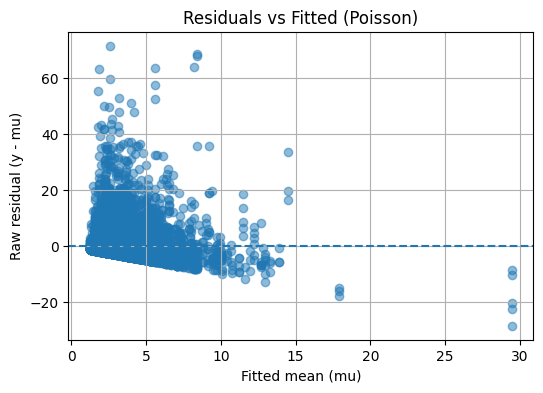

In [9]:
# plot residuals vs fitted
plt.figure(figsize=(6,4))
plt.scatter(fit["mu"], y - fit["mu"], alpha=0.5)

# horizontal line at y = 0
plt.axhline(0, ls="--")

# label, title, display
plt.xlabel("Fitted mean (mu)")
plt.ylabel("Raw residual (y - mu)")
plt.title("Residuals vs Fitted (Poisson)")
plt.grid()
plt.show()
